<a href="https://colab.research.google.com/github/kosar-am/finance-prediction-rnn/blob/main/notebooks/06_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Stock Price Prediction using RNN, LSTM, and GRU

## 06 — Model Comparison

In this notebook, the performance of the RNN, LSTM, and GRU models is compared using evaluation metrics and visualization techniques.

### Objectives

- Load evaluation metrics from all models
- Compare model performance
- Visualize evaluation metrics
- Identify the best-performing model
- Summarize the experimental findings

## 📚 Import Required Libraries

In [21]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Setting Up Project Paths

In [22]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
RESULTS_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026/results"

In [24]:
PROJECT_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

## Load Evaluation Metrics

In [25]:
rnn_metrics = pd.read_csv(
    f"{RESULTS_PATH}/rnn_metrics.csv"
)

lstm_metrics = pd.read_csv(
    f"{RESULTS_PATH}/lstm_metrics.csv"
)

gru_metrics = pd.read_csv(
    f"{RESULTS_PATH}/gru_metrics.csv"
)

## MAE Comparison

In [26]:
metrics = pd.concat(
    [
        rnn_metrics,
        lstm_metrics,
        gru_metrics
    ],
    ignore_index=True
)

metrics

,Model,MAE,RMSE,R2
0,RNN,16.097142,27.319380,0.614765
1,LSTM,6.747881,9.832431,0.950099
2,GRU,4.390188,6.701887,0.976817


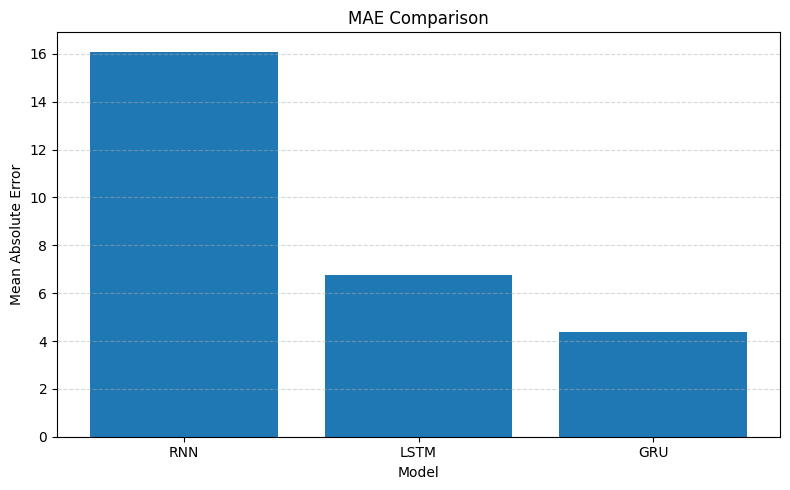

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    metrics["Model"],
    metrics["MAE"]
)

plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The GRU model achieved the lowest MAE (4.3902), indicating the highest prediction accuracy among all models. The LSTM model also performed well, while the Simple RNN produced the largest prediction error. Overall, the results suggest that the GRU model is the most effective for predicting Google stock prices.del achieving the smallest average prediction error.

## RMSE Comparison

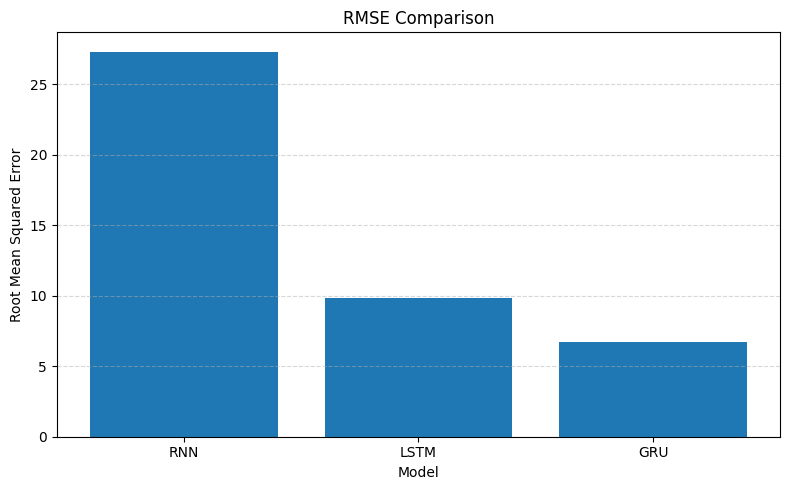

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    metrics["Model"],
    metrics["RMSE"]
)

plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The GRU model achieved the lowest RMSE (6.7019), indicating the smallest prediction error among the three models. The LSTM model also showed good performance with a considerably lower RMSE than the Simple RNN. In contrast, the RNN produced the highest RMSE, confirming its weaker ability to model Google stock price movements.

## R² Comparison

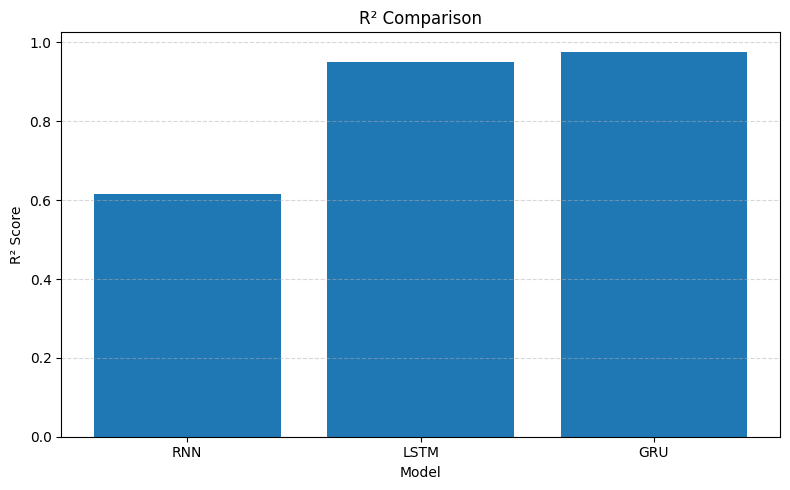

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    metrics["Model"],
    metrics["R2"]
)

plt.title("R² Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The GRU model achieved the highest R² score (0.9768), indicating the best ability to explain the variation in Google stock prices. The LSTM model also showed excellent performance with an R² of 0.9501, while the Simple RNN obtained the lowest score (0.6148). These results confirm that the GRU model provides the best overall predictive performance.

## Overall Performance Comparison|


<Figure size 800x500 with 0 Axes>

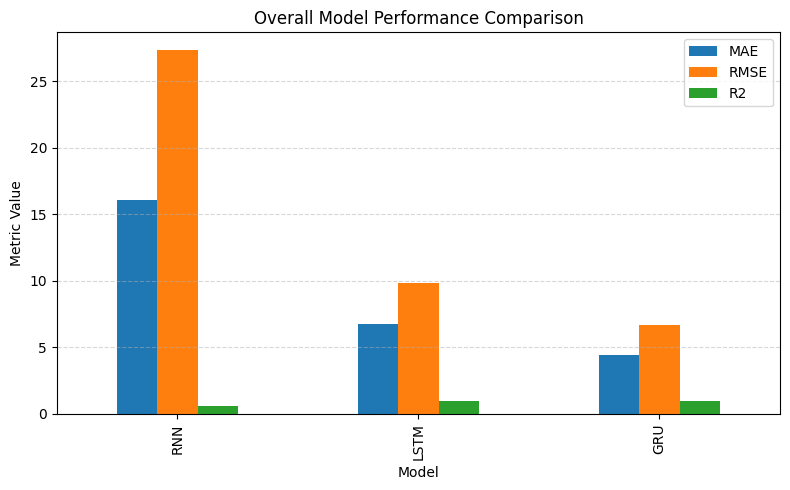

In [30]:
plt.figure(figsize=(8, 5))

metrics_plot = metrics.set_index("Model")

metrics_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Overall Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Metric Value")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/overall_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The overall comparison shows that the GRU model consistently achieved the best performance across all evaluation metrics. It recorded the lowest MAE and RMSE values together with the highest R² score. In comparison, the LSTM model performed well, while the Simple RNN showed the weakest overall performance.

## Best Model

In [31]:
best_model = metrics.loc[
    metrics["RMSE"].idxmin()
]

best_model

,2
Model,GRU
MAE,4.390188
RMSE,6.701887
R2,0.976817


## Summary

In [32]:
print(f"Best Model: {best_model['Model']}")
print(f"MAE: {best_model['MAE']:.4f}")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"R²: {best_model['R2']:.4f}")

Best Model: GRU
MAE: 4.3902
RMSE: 6.7019
R²: 0.9768


## Save Comparison Results

In [33]:
metrics.to_csv(
    f"{RESULTS_PATH}/model_comparison.csv",
    index=False
)

metrics

,Model,MAE,RMSE,R2
0,RNN,16.097142,27.319380,0.614765
1,LSTM,6.747881,9.832431,0.950099
2,GRU,4.390188,6.701887,0.976817


## Conclusion

This project compared the performance of Simple RNN, LSTM, and GRU models for predicting Google stock prices. Based on the evaluation metrics, the GRU model achieved the best overall performance with the lowest MAE (4.3902), the lowest RMSE (6.7019), and the highest R² score (0.9768). Although the LSTM model also produced accurate predictions, the GRU model demonstrated greater accuracy and better generalization. In contrast, the Simple RNN showed the weakest performance, indicating its limitations in capturing complex temporal patterns. Overall, the results suggest that the GRU model is the most suitable approach for this stock price prediction task.